# MenoPhenotype — Exploratory Data Analysis

**Project:** Unsupervised discovery of menopausal symptom phenotypes (clustering)

This notebook covers **Part 1: EDA** for the two source datasets you uploaded. Both come from
the **Study of Women's Health Across the Nation (SWAN)**, the same longitudinal cohort study
named in the project blueprint (Section 6). They are identified by their ICPSR study numbers:

| File | ICPSR Study | Official Title | N (rows) | N (cols) |
|---|---|---|---|---|
| `28762-0001-Data.csv` | 28762 | SWAN Baseline Dataset, 1996–1997 | 3,302 | 741 |
| `04368-0001-Data.csv` | 04368 | SWAN Cross-Sectional Screener Data | 16,142 | 111 |

**How they relate:** the Screener (04368) was fielded first, to a broad community sample of
~16k midlife women, to determine eligibility for the longitudinal study. A subset of ~3.3k of
those women were then enrolled and given the much more detailed Baseline interview (28762) —
confirmed below: every `SWANID` in the Baseline file is also present in the Screener file.

## What each dataset gives us for this project

**`28762` — SWAN Baseline (the primary modeling dataset)**
This is the rich, detailed dataset and should be the main source of clustering features:
- **Symptom checklist, frequency-coded** (not just yes/no): hot flashes, night sweats, cold
  sweats, vaginal dryness, joint stiffness, forgetfulness, irritability, feeling blue, trouble
  sleeping, waking early, heart racing, headaches — each scored on a "days in the past 2 weeks"
  scale (`Not At All` → `1-5 Days` → `6-8 Days` → `9-13 Days` → `Every Day`). This is exactly
  the graded severity data the blueprint's clustering task needs (Section 6, "Candidate
  features").
- **Hormonal/clinical panel** (Section 6 explicitly wants this and it's rare in public data):
  FSH, estradiol (`E2AVE0`), testosterone (`T0`), TSH, SHBG, DHEA-S (`DHAS0`).
  This is a strong differentiator vs. most public menopause datasets.
  This is a strong differentiator vs. most public menopause datasets.
- **Anthropometrics/vitals:** BMI, waist/hip, blood pressure, pulse.
  - CESD-derived depression items (`BOTHER0`, `BLUES0`, `DEPRESS0`, etc.) for a richer
  psychological-symptom axis than the single "feeling blue" item.
- **Demographics/lifestyle:** age, race, smoking, diet (extensive FFQ variables), physical
  activity, work/shift schedule.
- **Menopausal staging (`STATUS0`)** — held out and used only for *post-hoc* validation of
  clusters, never as a clustering input, per Section 5/9 of the blueprint.

**`04368` — SWAN Screener (a large-N validation / demographic-context dataset)**
This is a much larger (16k) but shallower dataset: a simple **binary yes/no** symptom checklist
(`HOTFLASH`, `NISWEAT`, `STIFF`, `HEADACH`, `FORGET`, `TENSE`, `DEPRESS`, `DRYNESS`, `IRRITAB`,
`HEARTBO`, `URINE`), plus `STATUS` (a *finer* 5-level menopausal-stage variable — pre / early
peri / late peri / natural post / undetermined), BMI, race, and some psychosocial/quality-of-life
items. Its main uses in this project:
1. **External validation set** for cluster stability at much larger N (Section 9: "Stability").
2. **A finer-grained `STATUS` label** than Baseline's 3-category `STATUS0`, useful for post-hoc
   cross-tabulation against discovered clusters (Section 9: "Post-hoc clinical validity").
3. Since it's *screening* data, its binary symptom coding is coarser — not ideal as the primary
   clustering input, but useful for a simplified/robustness-check clustering pass.

Below we EDA each dataset in turn.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

pd.set_option('display.max_columns', 60)
pd.set_option('display.width', 140)
sns.set_theme(style='whitegrid', palette='Set2')
plt.rcParams['figure.dpi'] = 100

BASELINE_PATH = 'data/swan_baseline_28762.csv'   # ICPSR 28762
SCREENER_PATH = 'data/swan_screener_04368.csv'   # ICPSR 04368


## Part A — SWAN Baseline (ICPSR 28762)

### A.1 Load & basic structure


In [2]:
baseline = pd.read_csv(BASELINE_PATH, low_memory=False)
print(f"Shape: {baseline.shape[0]:,} women x {baseline.shape[1]:,} columns")
print(f"Unique SWANID: {baseline['SWANID'].nunique():,}  (no duplicate participants: {baseline['SWANID'].nunique() == len(baseline)})")
print(f"All rows are VISIT == 0 (baseline visit): {(baseline['VISIT'] == 0).all()}")
baseline.head(3)


Shape: 3,302 women x 741 columns
Unique SWANID: 3,302  (no duplicate participants: True)
All rows are VISIT == 0 (baseline visit): True


,SWANID,VISIT,INTDAY0,AGE0,PREGNAN0,PREVBLO0,ALCHL240,EATDRIN0,STRTPER0,BLDRWAT0,BLDDRAW0,ANTICOA0,ACOAYS0,HEART0,HARTYS0,ULCER0,ULCRYS0,CHOLEST0,CHOLYS0,BP0,BPYS0,THYROID0,THYRYS0,INSULIN0,INSUYS0,NERVOUS0,NERVYS0,STEROID0,STERYS0,INHALER0,...,CHOLRES0,FACRESU0,FIBRESU0,GLUCRES0,HDLRESU0,INSURES0,LDLRESU0,LPARESU0,PAIRESU0,TPARESU0,TRIGRES0,LPA1RES0,APOARES0,APOBRES0,CRPRESU0,FLAGCO20,FLAGSER0,SPSCDAY0,SPSCTIM0,SPSCMOD0,HPSCDAY0,HPSCTIM0,HPSCMOD0,SPBMDT0,HPBMDT0,BMDFLG0,STATUS0,LMPDAY0,OCCUP0,RACE
0,10005,0,0,48.0,No,NaN,No,No,Yes,"Yes, as per protocol",Yes,No,NaN,No,NaN,No,NaN,No,NaN,No,NaN,No,NaN,No,NaN,Yes,Yes,No,NaN,No,...,137.0,151.0,298.0,102.0,40.0,7.2,73.0,22.0,38.0,8.5,122.0,46.0,114.0,78.0,3.1,No,No,NaN,.,NaN,NaN,.,NaN,NaN,NaN,NaN,NaN,NaN,Hairdressers & cosmetologists,Hispanic
1,10046,0,0,52.0,No,NaN,No,No,Yes,"Yes, as per protocol",Yes,No,NaN,No,NaN,No,NaN,No,NaN,No,NaN,No,NaN,No,NaN,No,NaN,No,NaN,No,...,221.0,159.0,265.0,100.0,57.0,13.7,136.0,8.0,46.1,8.2,138.0,46.0,191.0,142.0,1.6,No,No,0.0,0:09:03,2000 machine,0.0,0:08:53,5: 2000 machine,1.1163,0.9280,NaN,Early Peri,-35.0,General office clerks,Chinese/Chinese American
2,10056,0,0,51.0,No,No,Yes,No,Yes,"Yes, as per protocol",Yes,No,NaN,No,NaN,No,NaN,No,NaN,No,NaN,No,NaN,No,NaN,No,NaN,No,NaN,No,...,176.0,104.0,199.0,88.0,76.0,4.3,85.0,34.0,4.6,4.4,75.0,68.0,169.0,81.0,0.3,No,No,75.0,0:15:07,4500 machine,75.0,0:15:17,11: 4500 machine,0.8954,0.8547,NaN,Pre-menopausal,-57.0,NaN,Caucasian/White Non-Hispanic


### A.2 Selecting the candidate feature groups

`28762` has 741 columns, most of which (diet frequency questionnaire, detailed pregnancy/
breastfeeding history, reproductive surgery history, etc.) are out of scope for symptom
phenotyping. We define named column groups matching the blueprint's Section 6 feature list, so
the rest of this EDA — and the later clustering notebook — can pull from these groups directly.


In [3]:
feature_groups = {
    'vasomotor': ['HOTFLAS0', 'NITESWE0', 'COLDSWE0', 'FLASHPH0', 'FLASHEB0', 'FLASHEM0'],
    'psychological': ['FEELBLU0', 'IRRITAB0', 'NRVOUS0', 'FORGET0', 'MOODCHG0', 'FEARFULA0'],
    'somatic_physical': ['STIFF0', 'HDACHE0', 'VAGINDR0', 'HARTRAC0', 'DIZZY0', 'LEAKURI0'],
    'sleep': ['TRBLSLE0', 'WAKEUP0', 'WAKEARL0'],
    'hormonal': ['FSH0', 'E2AVE0', 'T0', 'TSH0', 'SHBG0', 'DHAS0'],
    'anthropometric_vitals': ['BMI0', 'WAIST0', 'HIP0', 'PULSE0', 'SYSBP10', 'DIABP10'],
    'cesd_depression': ['BOTHER0', 'APPETIT0', 'BLUES0', 'GOOD0', 'KEEPMIN0', 'DEPRESS0',
                         'EFFORT0', 'HOPEFUL0', 'FAILURE0', 'FEARFUL0', 'RESTLES0', 'HAPPY0',
                         'TALKLES0', 'LONELY0'],
    'demographic_lifestyle': ['AGE0', 'RACE', 'SMOKERE0', 'PHY_ACT' if 'PHY_ACT' in baseline.columns else 'SPORTS0'],
    'validation_only': ['STATUS0'],   # held out from clustering, used post-hoc only
}

for group, cols in feature_groups.items():
    present = [c for c in cols if c in baseline.columns]
    missing = [c for c in cols if c not in baseline.columns]
    print(f"{group:22s}: {len(present)}/{len(cols)} found" + (f"  (missing: {missing})" if missing else ""))


vasomotor             : 6/6 found
psychological         : 6/6 found
somatic_physical      : 6/6 found
sleep                 : 3/3 found
hormonal              : 6/6 found
anthropometric_vitals : 6/6 found
cesd_depression       : 14/14 found
demographic_lifestyle : 4/4 found
validation_only       : 1/1 found


### A.3 Missingness overview across all 741 columns

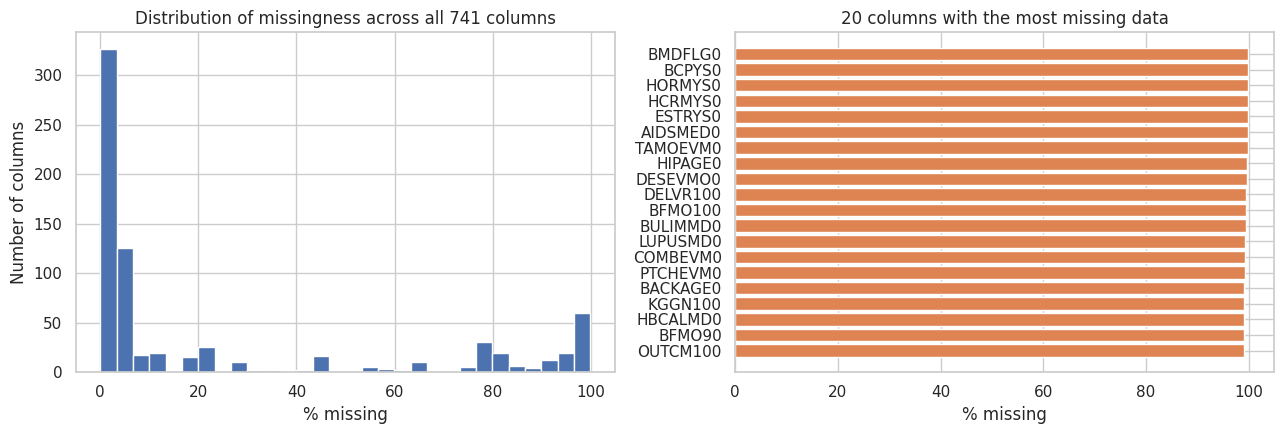

Columns with 0% missing: 116
Columns with >50% missing: 177
Columns with >90% missing: 91


In [4]:
missing_pct = baseline.isna().mean().sort_values(ascending=False) * 100

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

axes[0].hist(missing_pct, bins=30, color='#4C72B0', edgecolor='white')
axes[0].set_title('Distribution of missingness across all 741 columns')
axes[0].set_xlabel('% missing')
axes[0].set_ylabel('Number of columns')

top20 = missing_pct.head(20)
axes[1].barh(top20.index[::-1], top20.values[::-1], color='#DD8452')
axes[1].set_title('20 columns with the most missing data')
axes[1].set_xlabel('% missing')
plt.tight_layout()
plt.show()

print(f"Columns with 0% missing: {(missing_pct == 0).sum()}")
print(f"Columns with >50% missing: {(missing_pct > 50).sum()}")
print(f"Columns with >90% missing: {(missing_pct > 90).sum()}")


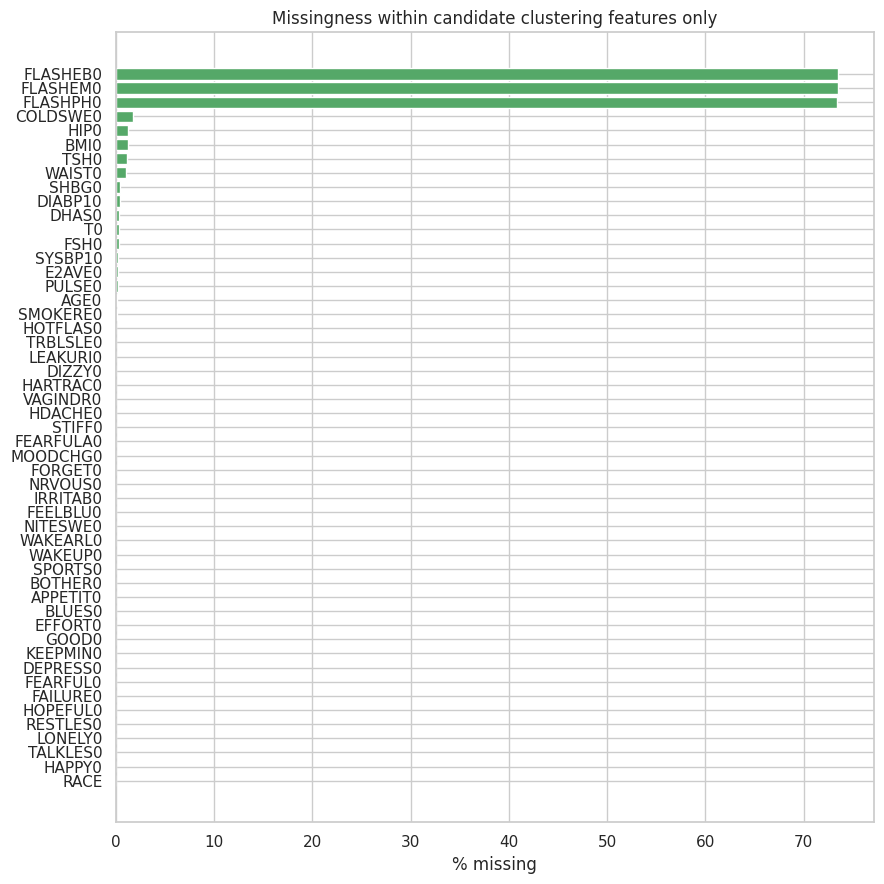


Good news: candidate feature missingness is low overall -- max is: 73.5% -- imputation will be light-touch (Section 11 challenge noted).


In [5]:
# Missingness specifically within our candidate clustering feature groups -- these are what matter most
core_cols = sum([cols for g, cols in feature_groups.items() if g != 'validation_only'], [])
core_cols = [c for c in core_cols if c in baseline.columns]
core_missing = baseline[core_cols].isna().mean().sort_values(ascending=False) * 100

plt.figure(figsize=(9, 9))
plt.barh(core_missing.index[::-1], core_missing.values[::-1], color='#55A868')
plt.xlabel('% missing')
plt.title('Missingness within candidate clustering features only')
plt.tight_layout()
plt.show()

print("\nGood news: candidate feature missingness is low overall -- max is:",
      f"{core_missing.max():.1f}%", "-- imputation will be light-touch (Section 11 challenge noted).")


### A.4 Demographics: age, race, BMI

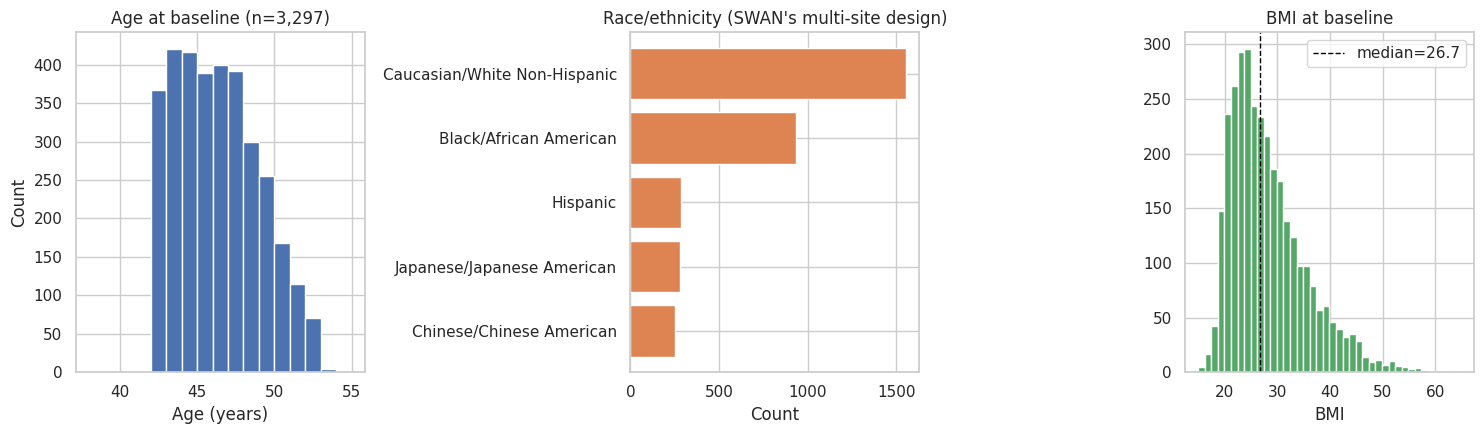

count    3297.0
mean       45.8
std         2.7
min        42.0
25%        44.0
50%        46.0
75%        48.0
max        53.0
Name: AGE0, dtype: float64


In [6]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

axes[0].hist(baseline['AGE0'].dropna(), bins=range(38, 56), color='#4C72B0', edgecolor='white')
axes[0].set_title(f"Age at baseline (n={baseline['AGE0'].notna().sum():,})")
axes[0].set_xlabel('Age (years)')
axes[0].set_ylabel('Count')

race_counts = baseline['RACE'].value_counts()
axes[1].barh(race_counts.index[::-1], race_counts.values[::-1], color='#DD8452')
axes[1].set_title('Race/ethnicity (SWAN\'s multi-site design)')
axes[1].set_xlabel('Count')

axes[2].hist(baseline['BMI0'].dropna(), bins=40, color='#55A868', edgecolor='white')
axes[2].axvline(baseline['BMI0'].median(), color='black', linestyle='--', linewidth=1,
                label=f"median={baseline['BMI0'].median():.1f}")
axes[2].set_title('BMI at baseline')
axes[2].set_xlabel('BMI')
axes[2].legend()

plt.tight_layout()
plt.show()

print(baseline['AGE0'].describe().round(1))


### A.5 Menopausal status (`STATUS0`) — held out for post-hoc validation only

Per the blueprint, this variable must **not** be a clustering input, but we look at it now
because (a) it's a useful sanity check on cohort composition, and (b) we'll cross-tabulate
discovered clusters against it later, so it's worth understanding its distribution up front.


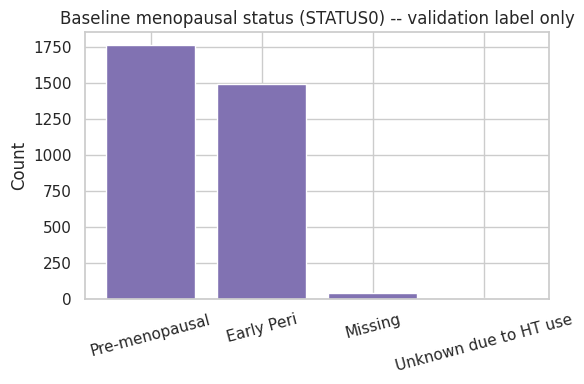

STATUS0
Pre-menopausal           1761
Early Peri               1493
NaN                        42
Unknown due to HT use       6
Name: count, dtype: int64

Note: Baseline-cohort SWAN inclusion criteria required women to still be pre- or early-
perimenopausal at entry, which is why 'Late Peri' / 'Post' are absent/rare here -- by design,
not missingness. The Screener dataset (Part B) captures the fuller menopausal spectrum.


In [7]:
status_counts = baseline['STATUS0'].value_counts(dropna=False)
status_labels = [str(v) if pd.notna(v) else 'Missing' for v in status_counts.index]
plt.figure(figsize=(6, 4))
plt.bar(status_labels, status_counts.values, color='#8172B2')
plt.title('Baseline menopausal status (STATUS0) -- validation label only')
plt.ylabel('Count')
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()
print(status_counts)
print("\nNote: Baseline-cohort SWAN inclusion criteria required women to still be pre- or early-\n"
      "perimenopausal at entry, which is why 'Late Peri' / 'Post' are absent/rare here -- by design,\n"
      "not missingness. The Screener dataset (Part B) captures the fuller menopausal spectrum.")


### A.6 Core symptom variables: distributions (the main clustering inputs)

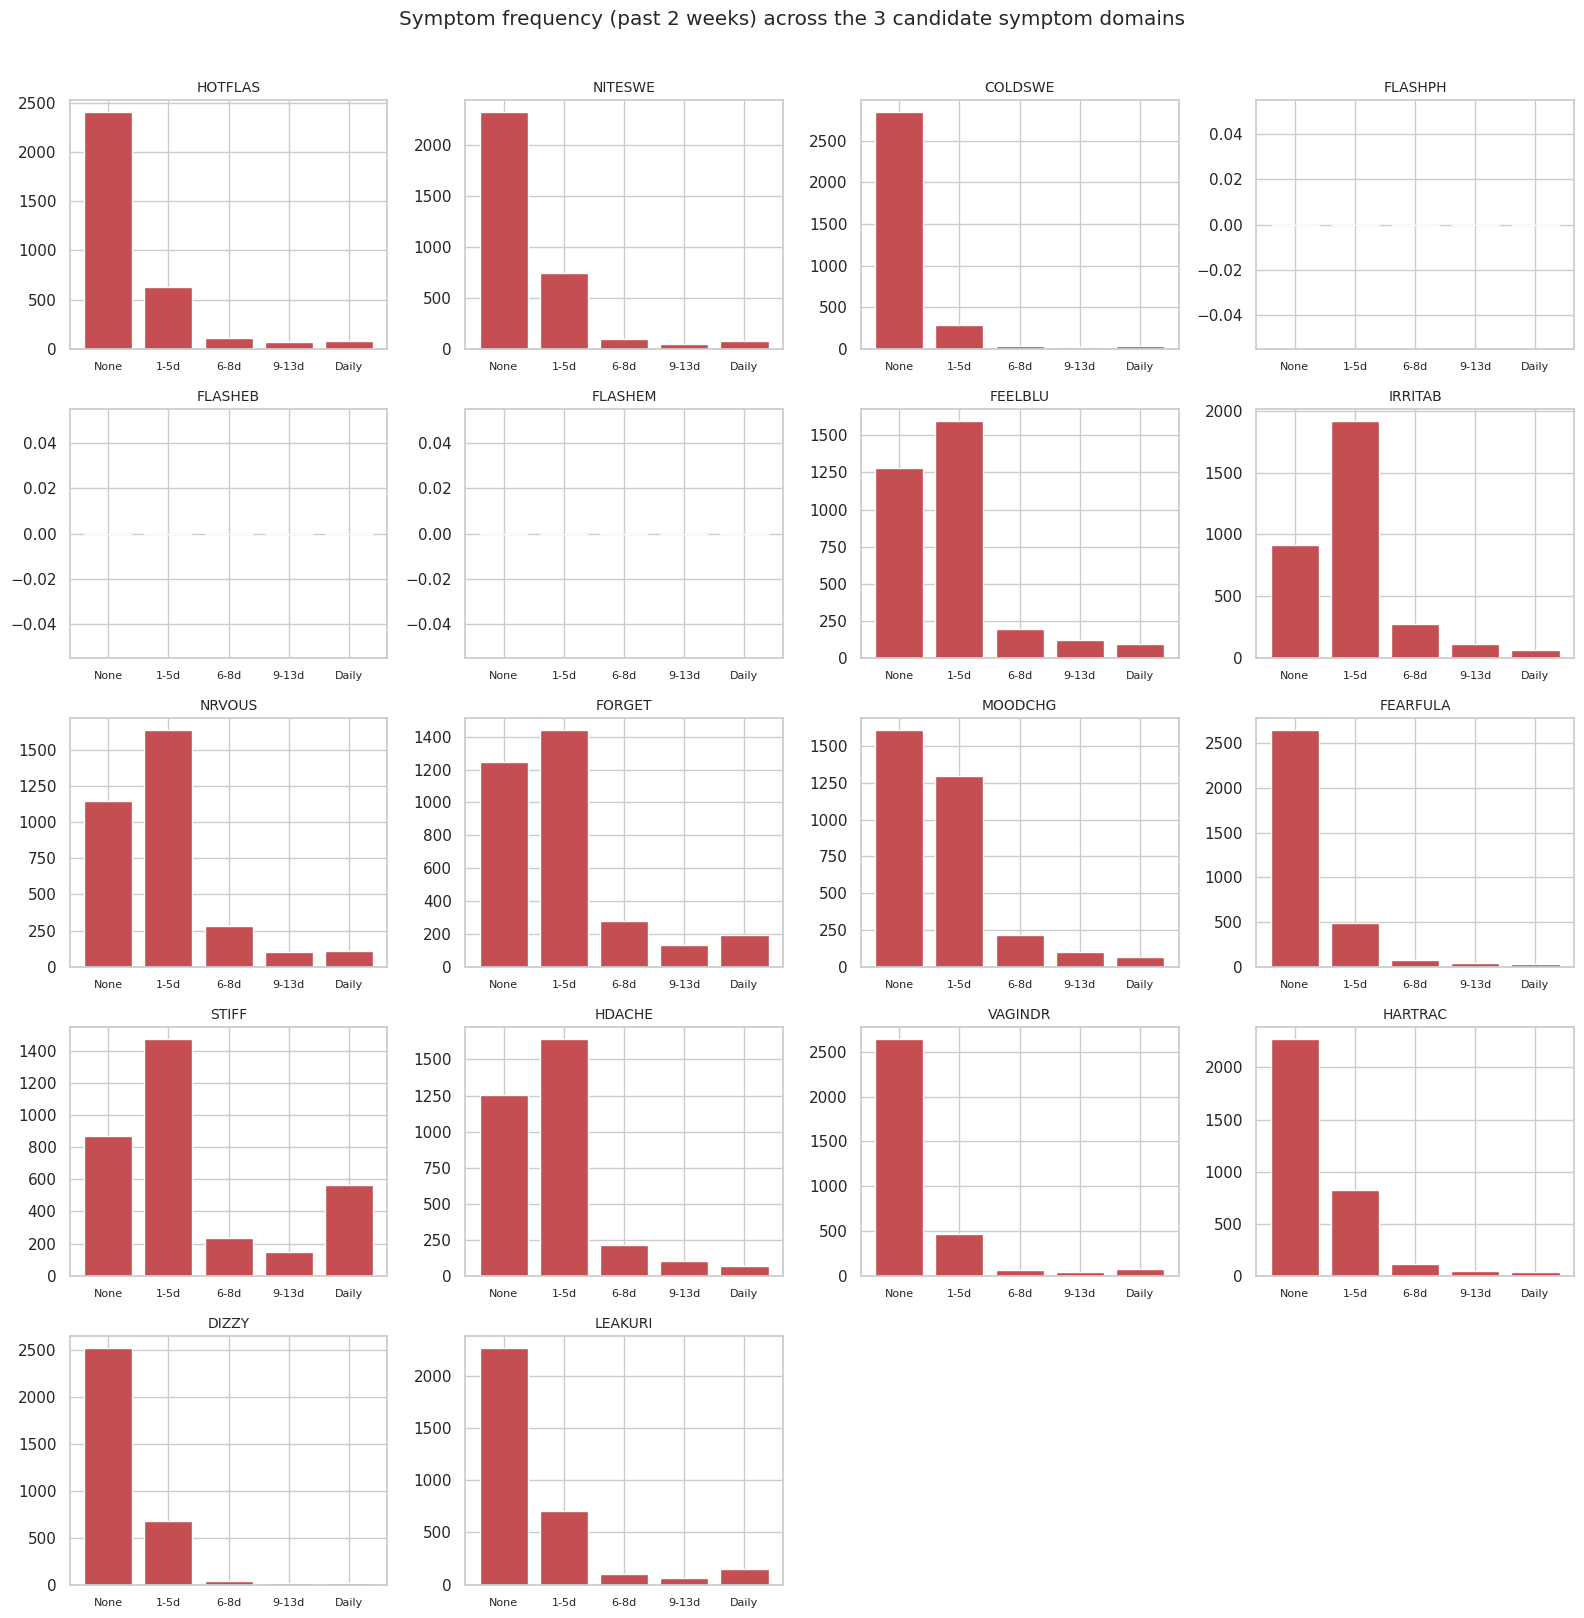

In [8]:
symptom_cols = feature_groups['vasomotor'] + feature_groups['psychological'] + \
               feature_groups['somatic_physical']
symptom_cols = [c for c in symptom_cols if c in baseline.columns]

freq_order = ['Not At All', '1-5 Days', '6-8 Days', '9-13 Days', 'Every Day']

n = len(symptom_cols)
ncols = 4
nrows = int(np.ceil(n / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(16, 3.2 * nrows))
axes = axes.flatten()

for i, col in enumerate(symptom_cols):
    vc = baseline[col].value_counts()
    ordered = [vc.get(level, 0) for level in freq_order]
    axes[i].bar(range(len(freq_order)), ordered, color='#C44E52')
    axes[i].set_xticks(range(len(freq_order)))
    axes[i].set_xticklabels(['None', '1-5d', '6-8d', '9-13d', 'Daily'], rotation=0, fontsize=8)
    axes[i].set_title(col.replace('0', ''), fontsize=10)

for j in range(i + 1, len(axes)):
    axes[j].axis('off')

plt.suptitle('Symptom frequency (past 2 weeks) across the 3 candidate symptom domains', y=1.01)
plt.tight_layout()
plt.show()


**Read on this:** vasomotor symptoms (hot flashes / night sweats) are heavily right-skewed —
most women report "Not At All" with a long tail into "Every Day" — while several
somatic/psychological items (joint stiffness, irritability, forgetfulness) are much more evenly
spread across frequency levels. This heterogeneity in shape across domains is exactly the kind
of signal that supports the blueprint's premise (Section 2) that women cluster into distinct
symptom-dominant subgroups rather than a single severity axis.


### A.7 Symptom co-occurrence / correlation structure

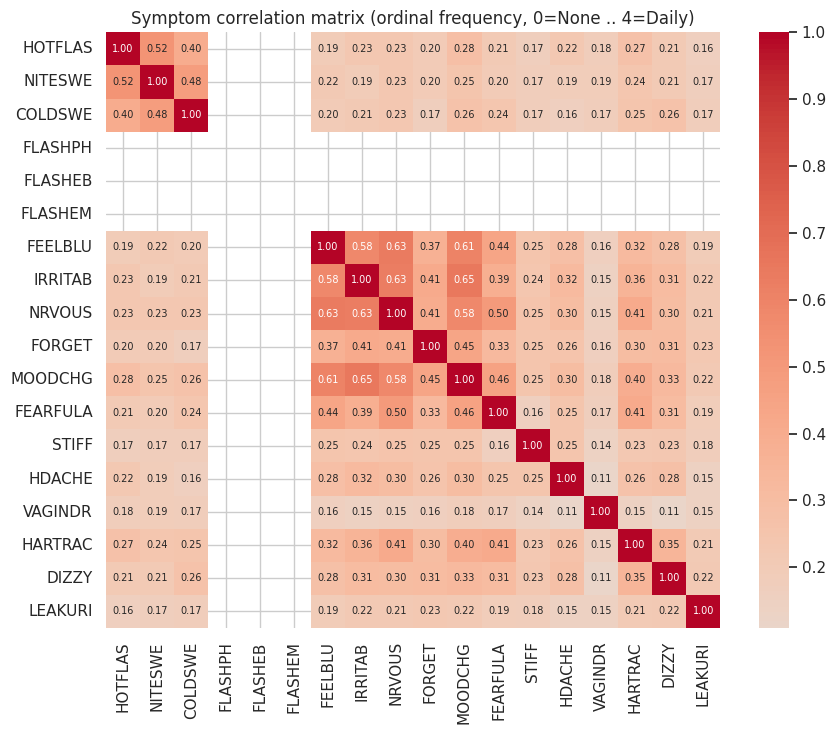

In [9]:
# Convert ordinal frequency labels to numeric 0-4 for a correlation view
freq_map = {'Not At All': 0, '1-5 Days': 1, '6-8 Days': 2, '9-13 Days': 3, 'Every Day': 4}
symptom_numeric = baseline[symptom_cols].apply(lambda s: s.map(freq_map))

corr = symptom_numeric.corr()
plt.figure(figsize=(9, 7.5))
sns.heatmap(corr, cmap='coolwarm', center=0, annot=True, fmt='.2f', annot_kws={'size': 7},
            xticklabels=[c.replace('0', '') for c in corr.columns],
            yticklabels=[c.replace('0', '') for c in corr.columns])
plt.title('Symptom correlation matrix (ordinal frequency, 0=None .. 4=Daily)')
plt.tight_layout()
plt.show()


**Read on this:** hot flashes and night sweats correlate most strongly with each other (as
expected — both vasomotor), while psychological items (irritability, forgetfulness, feeling
blue) form their own tighter correlated block. No pair is highly collinear (all |r| well below
0.7), meaning each symptom still carries distinct information — good news for clustering, since
none of these features are redundant duplicates of another.


### A.8 Hormonal panel: distributions

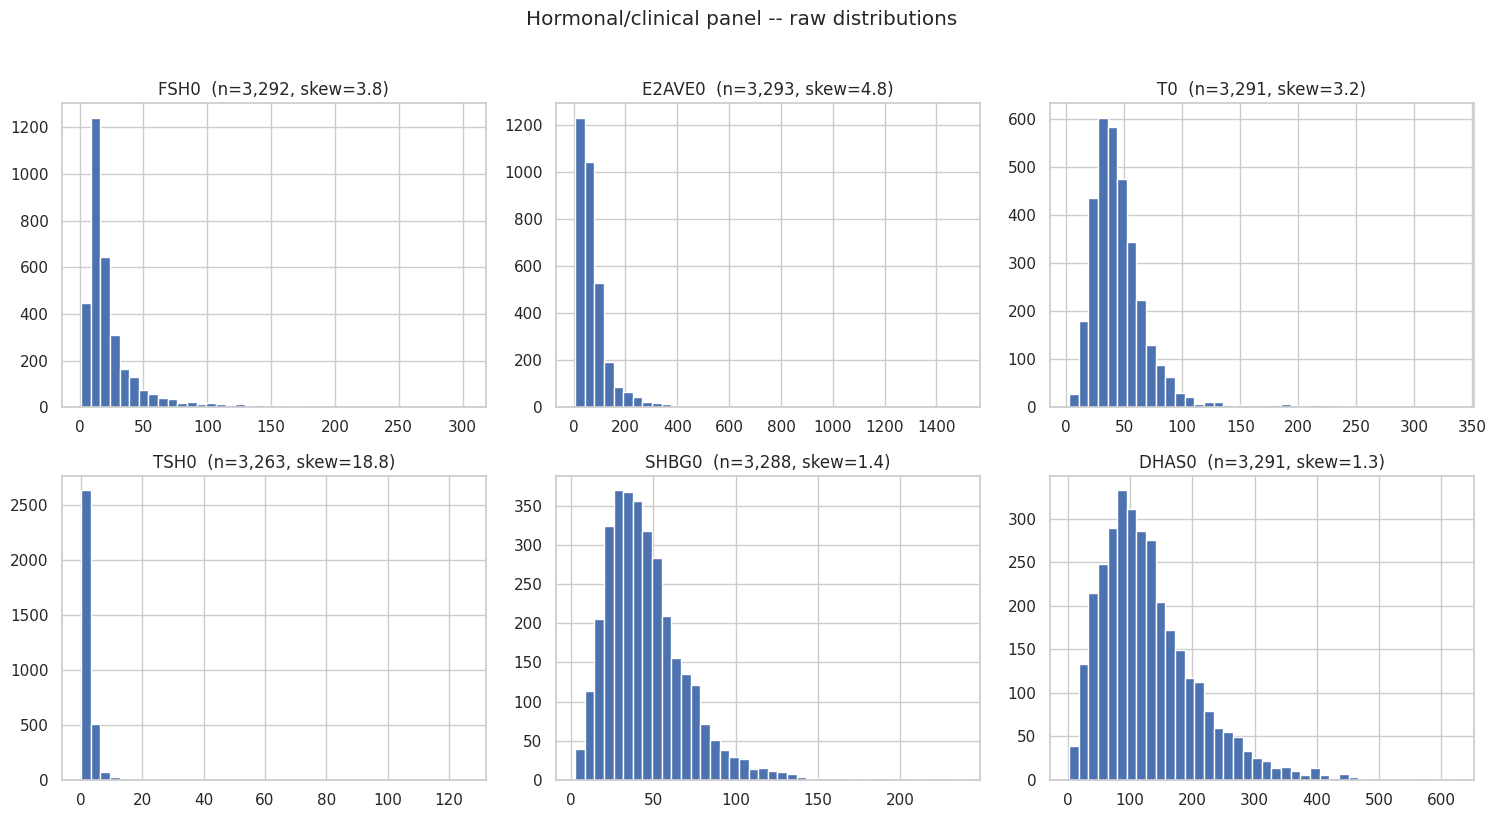

         count    mean    std   min    25%     50%     75%      max
FSH0    3292.0   24.44  26.49  1.11  10.80   15.90   26.40   303.20
E2AVE0  3293.0   76.74  80.42  5.40  33.00   55.15   88.70  1493.55
T0      3291.0   46.95  29.04  2.40  29.70   41.50   56.24   334.80
TSH0    3263.0    2.58   4.58  0.03   1.33    1.91    2.85   125.74
SHBG0   3288.0   45.34  24.56  2.30  28.10   41.00   57.50   236.70
DHAS0   3291.0  129.77  78.95  1.80  74.49  113.90  169.10   621.50


In [10]:
hormone_cols = [c for c in feature_groups['hormonal'] if c in baseline.columns]
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()
for i, col in enumerate(hormone_cols):
    data = baseline[col].dropna()
    axes[i].hist(data, bins=40, color='#4C72B0', edgecolor='white')
    axes[i].set_title(f"{col}  (n={len(data):,}, skew={data.skew():.1f})")
plt.suptitle('Hormonal/clinical panel -- raw distributions', y=1.02)
plt.tight_layout()
plt.show()

print(baseline[hormone_cols].describe().round(2).T)


**Read on this:** FSH, estradiol (`E2AVE0`), and DHEA-S are all strongly right-skewed, which is
expected for hormone assay data and typically calls for a log-transform before use in
distance-based clustering (K-Means, GMM) — worth flagging now for the preprocessing notebook.


### A.9 Do symptoms track with hormones? (sanity check, not causal)

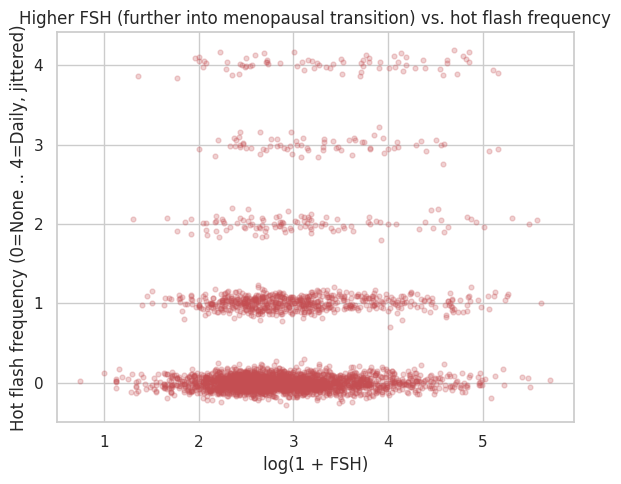

Spearman correlation (FSH vs hot flash frequency): 0.118


In [11]:
plt.figure(figsize=(6, 5))
plt.scatter(np.log1p(baseline['FSH0']), symptom_numeric['HOTFLAS0'] + np.random.normal(0, 0.08, len(baseline)),
            alpha=0.25, s=12, color='#C44E52')
plt.xlabel('log(1 + FSH)')
plt.ylabel('Hot flash frequency (0=None .. 4=Daily, jittered)')
plt.title('Higher FSH (further into menopausal transition) vs. hot flash frequency')
plt.tight_layout()
plt.show()

valid = baseline[['FSH0']].join(symptom_numeric['HOTFLAS0']).dropna()
print('Spearman correlation (FSH vs hot flash frequency):',
      valid.corr(method='spearman').iloc[0, 1].round(3))


**Read on this:** there's a positive but modest association between FSH (which rises as women
move through the menopausal transition) and hot-flash frequency — consistent with, but not a
substitute for, using menopausal staging as a post-hoc validation label rather than a strong
predictive relationship on its own. This also confirms hormones and symptoms carry
complementary, not duplicate, information.


## Part B — SWAN Screener (ICPSR 04368)

### B.1 Load & basic structure


In [12]:
screener = pd.read_csv(SCREENER_PATH, low_memory=False)
print(f"Shape: {screener.shape[0]:,} women x {screener.shape[1]:,} columns")
print(f"Unique SWANID: {screener['SWANID'].nunique():,}")

overlap = set(baseline['SWANID']).intersection(set(screener['SWANID']))
print(f"\nSWANIDs shared with Baseline (28762): {len(overlap):,} "
      f"({len(overlap) / len(baseline):.0%} of Baseline, {len(overlap) / len(screener):.1%} of Screener)")
print("--> Confirms Baseline is a clinically-deepened subset of the larger Screener sample.")
screener.head(3)


Shape: 16,142 women x 111 columns
Unique SWANID: 16,142

SWANIDs shared with Baseline (28762): 3,302 (100% of Baseline, 20.5% of Screener)
--> Confirms Baseline is a clinically-deepened subset of the larger Screener sample.


,SWANID,HEALTH,LVISIT,HIGH_BP,MHIGHBP,DIABETE,MDIABET,HEART,MHEART,ARTHRIT,MARTHR,OSTEOPR,MOSTEOP,FIBROID,MFIBROD,CANCER,MCANCER,DIFFISLP,NISWEAT,STIFF,HEADACH,HOTFLASH,FORGET,TENSE,DEPRESS,DRYNESS,IRRITAB,HEARTBO,URINE,LIMITED,...,WORK,TOTALHRS,MARITALGP,HOW_HARD,RACE,IND_1A,IND_1B,IND_1C,IND_1D,IND_1E,AGE,LMPMOS,STATUS,MEN_FLAG,HORMEVER,SMOKER,SMOKING,NUM_CIG,DEGREE,P_STRESS,SF36PF,NSF36,DISABLE,BMI,BMI_FLAG,WTKGGP,AGE_R_HYST,AGE_R_OOPH,AGE_R_LMP,NUMCHILD
0,10005,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,Hispanic,NaN,NaN,NaN,NaN,NaN,48,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,10009,Excellent,At least 1 but less than 3 years,No,NaN,Yes,Yes,No,NaN,Yes,No,No,NaN,Yes,No,No,NaN,No,Yes,Yes,Yes,Yes,Yes,No,No,No,Yes,No,Yes,No,...,Yes,35 hours or more,Widowed,Somewhat hard,Black/African American,Yes,No,No,No,No,49,NaN,Natural post,No,Ever used hormones,Not a current smoker,Never smoked,0.0,Some college/technical school,11.0,Does not have a disability or is not limited b...,10.0,Not,40.04,Body Mass Index (BMI) acceptable range,111-115.99 kgs,NaN,NaN,43.0,3 children
2,10011,Good,Less than 1 year,Yes,No,No,NaN,No,NaN,Yes,No,No,NaN,No,NaN,Yes,No,No,No,No,Yes,No,No,Yes,Yes,Yes,Yes,No,Yes,No,...,Yes,35 hours or more,Separated or divorced,Not very hard at all,Black/African American,Yes,No,No,No,No,49,NaN,NaN,No,Never used hormones,Not a current smoker,Never smoked,0.0,Post graduate education,4.0,Does not have a disability or is not limited b...,10.0,Not,28.37,Body Mass Index (BMI) acceptable range,81-85.99 kgs,35.0,NaN,NaN,3 children


### B.2 Missingness overview

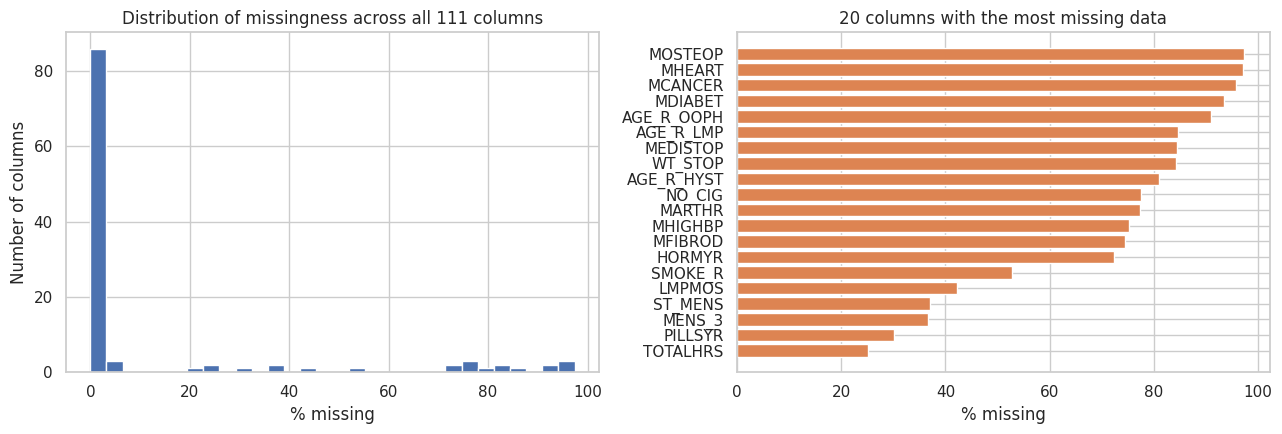

In [13]:
scr_missing = screener.isna().mean().sort_values(ascending=False) * 100
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

axes[0].hist(scr_missing, bins=30, color='#4C72B0', edgecolor='white')
axes[0].set_title('Distribution of missingness across all 111 columns')
axes[0].set_xlabel('% missing')
axes[0].set_ylabel('Number of columns')

top20 = scr_missing.head(20)
axes[1].barh(top20.index[::-1], top20.values[::-1], color='#DD8452')
axes[1].set_title('20 columns with the most missing data')
axes[1].set_xlabel('% missing')
plt.tight_layout()
plt.show()


Note the large chunk of very-high missingness columns visible on the left histogram: these are
mostly *conditional* follow-up questions (e.g., "at what age did you have a hysterectomy" only
asked of women who said yes to having one), not data-quality problems, and won't be used as
direct clustering inputs.


### B.3 Menopausal status (`STATUS`) — the finer-grained staging variable

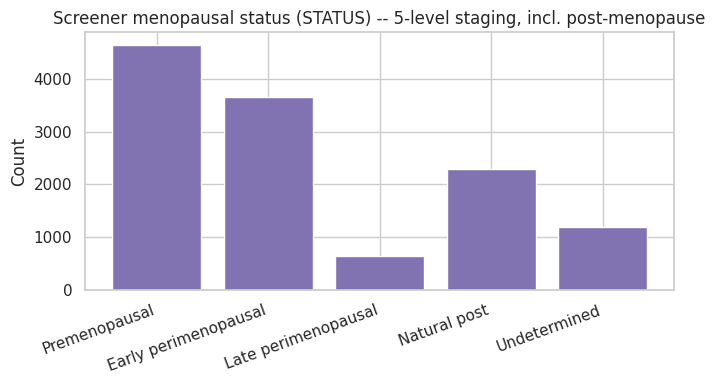

Missing STATUS: 3,714 (23.0%) -- typically women who were ineligible / not yet classified at screening.


In [14]:
status_order = ['Premenopausal', 'Early perimenopausal', 'Late perimenopausal',
                'Natural post', 'Undetermined']
status_counts_scr = screener['STATUS'].value_counts()
ordered = [status_counts_scr.get(s, 0) for s in status_order]

plt.figure(figsize=(7, 4))
plt.bar(status_order, ordered, color='#8172B2')
plt.title('Screener menopausal status (STATUS) -- 5-level staging, incl. post-menopause')
plt.ylabel('Count')
plt.xticks(rotation=20, ha='right')
plt.tight_layout()
plt.show()

missing_status = screener['STATUS'].isna().sum()
print(f"Missing STATUS: {missing_status:,} ({missing_status/len(screener):.1%}) "
      "-- typically women who were ineligible / not yet classified at screening.")


**Read on this:** unlike Baseline's `STATUS0` (which only spans pre-/early-peri because of the
cohort's enrollment criteria), the Screener's `STATUS` covers the **full menopausal spectrum**
including late perimenopausal and natural postmenopausal women. This makes it the better source
for post-hoc validation of clusters across the *whole* transition, even though its underlying
symptom items are coarser.


### B.4 Core symptom variables: binary yes/no rates

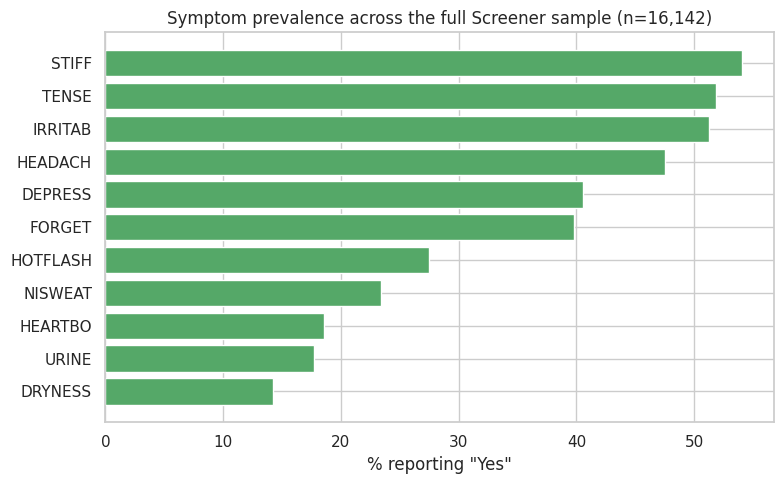

STIFF       54.1
TENSE       51.9
IRRITAB     51.2
HEADACH     47.5
DEPRESS     40.5
FORGET      39.8
HOTFLASH    27.5
NISWEAT     23.4
HEARTBO     18.6
URINE       17.7
DRYNESS     14.2
dtype: float64


In [15]:
scr_symptom_cols = ['HOTFLASH', 'NISWEAT', 'STIFF', 'HEADACH', 'FORGET', 'TENSE',
                     'DEPRESS', 'DRYNESS', 'IRRITAB', 'HEARTBO', 'URINE']
scr_symptom_cols = [c for c in scr_symptom_cols if c in screener.columns]

yes_rate = (screener[scr_symptom_cols] == 'Yes').mean().sort_values(ascending=False) * 100

plt.figure(figsize=(8, 5))
plt.barh(yes_rate.index[::-1], yes_rate.values[::-1], color='#55A868')
plt.xlabel('% reporting "Yes"')
plt.title(f'Symptom prevalence across the full Screener sample (n={len(screener):,})')
plt.tight_layout()
plt.show()
print(yes_rate.round(1))


### B.5 Symptom prevalence by menopausal stage (validation preview)

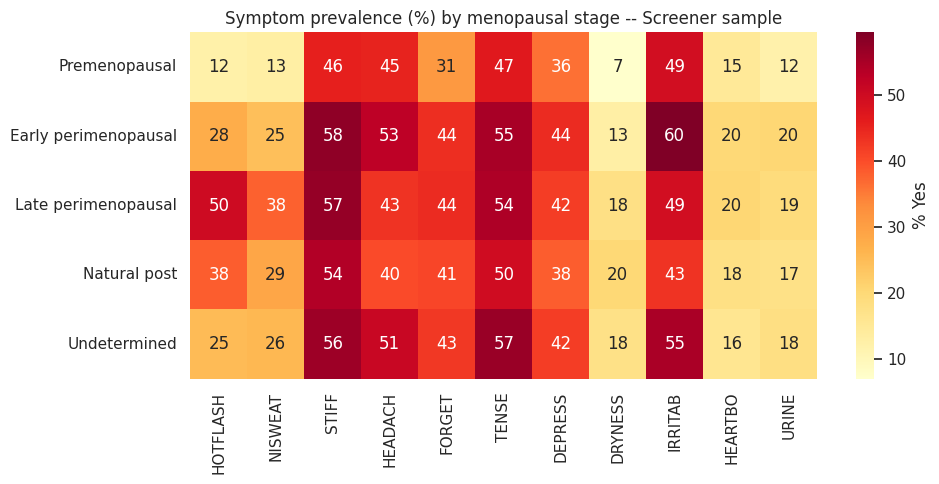

In [16]:
# Preview of the kind of post-hoc cross-tab the blueprint calls for (Section 9) -- here run
# against STATUS directly, as a sanity check that symptoms track with menopausal staging
# even before any clustering is done.
pivot = screener.groupby('STATUS')[scr_symptom_cols].apply(lambda d: (d == 'Yes').mean() * 100)
pivot = pivot.reindex(status_order)

plt.figure(figsize=(10, 5))
sns.heatmap(pivot, annot=True, fmt='.0f', cmap='YlOrRd', cbar_kws={'label': '% Yes'})
plt.title('Symptom prevalence (%) by menopausal stage -- Screener sample')
plt.xlabel('')
plt.ylabel('')
plt.tight_layout()
plt.show()


**Read on this:** vasomotor symptoms (hot flashes, night sweats) climb sharply from
premenopausal → late perimenopausal, as clinically expected, while some items (joint stiffness,
memory/forgetfulness) rise more gradually and stay elevated post-menopause. This is a useful
external sanity check well before any modeling: symptom patterns already visibly differ by
menopausal stage, supporting the premise that data-driven phenotypes should recover clinically
plausible structure.


### B.6 Demographics: BMI and race, for comparison with Baseline

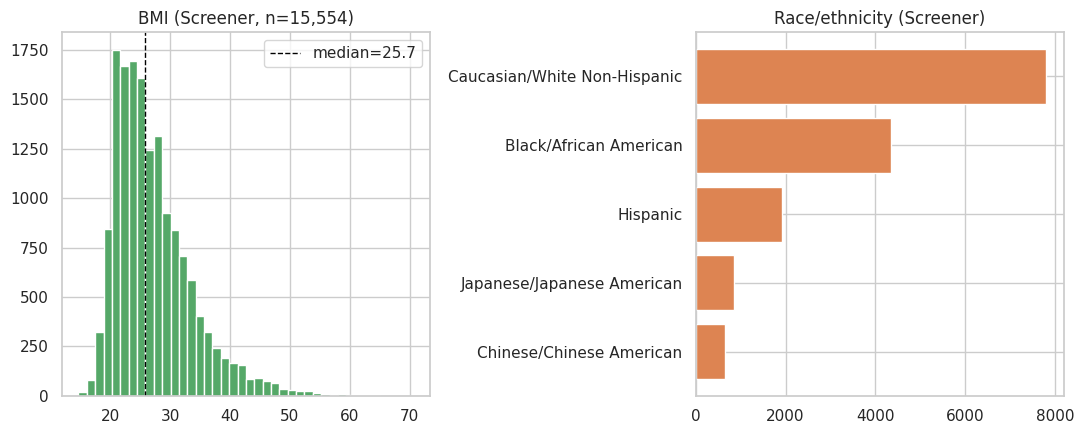

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

axes[0].hist(screener['BMI'].dropna(), bins=40, color='#55A868', edgecolor='white')
axes[0].axvline(screener['BMI'].median(), color='black', linestyle='--', linewidth=1,
                label=f"median={screener['BMI'].median():.1f}")
axes[0].set_title(f"BMI (Screener, n={screener['BMI'].notna().sum():,})")
axes[0].legend()

race_counts_scr = screener['RACE'].value_counts()
axes[1].barh(race_counts_scr.index[::-1], race_counts_scr.values[::-1], color='#DD8452')
axes[1].set_title('Race/ethnicity (Screener)')
plt.tight_layout()
plt.show()


## Part C — Summary & what this means for the next notebook (Preprocessing + Clustering)

**Dataset roles, confirmed by this EDA:**
- **`28762` (Baseline)** is the primary source for the unsupervised clustering model. Its
  frequency-graded symptom items, hormone panel, and CESD depression scale together closely
  match every candidate feature group named in the blueprint (Section 6), missingness on these
  fields is low, and no pair of symptoms is redundant enough to drop.
- **`04368` (Screener)** is best used for (a) a larger-N robustness/stability check with a
  simplified binary feature set, and (b) post-hoc validation of clusters against its finer
  5-level `STATUS` variable, which spans the menopausal transition more completely than
  Baseline's `STATUS0`.

**Preprocessing implications carried forward:**
1. Log-transform the hormone panel (FSH, E2, DHEA-S) before scaling — all strongly right-skewed.
2. Map the 5-level "days in past 2 weeks" symptom scale to ordinal 0–4 (already done above) for
   distance-based clustering; consider keeping the categorical version for tree-based post-hoc
   interpretation (Section 7's Decision Tree step).
3. Standardize all features before K-Means/GMM given the very different native scales (hormone
   ng/mL & pg/mL vs. 0–4 symptom scores vs. BMI).
4. `STATUS0` / `STATUS` are held out from the feature matrix entirely and reserved for post-hoc
   cross-tabulation, per Section 5.
5. Missingness is low enough for simple imputation (median for continuous, mode for ordinal) —
   no case for wholesale row-dropping.

Next notebook: preprocessing pipeline + PCA + K-Means/Agglomerative/DBSCAN/GMM sweep (Section 7).
